In [56]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
lookback=30
ann=252
target_vol=0.09
leverage_cap=1

In [58]:
Close=yf.download('AAL',start='2024-10-01')['Open']
ret=Close.pct_change().dropna().astype(float)

realized=ret.rolling(lookback).std()*np.sqrt(ann)
pos=(target_vol/realized.replace(0.0,np.nan)).clip(0.0,leverage_cap).fillna(0.0)

#s = pd.Series([1, 5, 10, 20])

# Clip values between 3 and 15
#clipped = s.clip(lower=3, upper=15)
#print(clipped)
#Output:

#makefile
#Copy
#Edit
#0     3   # 1 → clipped up to 3
#1     5   # stays 5
#2    10   # stays 10
#3    15   # 20 → clipped down to 15
#dtype: int64

pos

C:\Users\user\AppData\Local\Temp\ipykernel_5180\943312962.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Close=yf.download('AAL',start='2024-10-01')['Open']
[*********************100%***********************]  1 of 1 completed


Ticker,AAL
Date,
2024-10-02,0.000000
2024-10-03,0.000000
2024-10-04,0.000000
2024-10-07,0.000000
2024-10-08,0.000000
...,...
2025-08-13,0.189656
2025-08-14,0.191817
2025-08-15,0.192359


In [59]:
strat_ret=pos*ret.shift(-1)
bh_ret=ret
def equity(r):
    return(1.0+r).cumprod()
eq_strat=equity(strat_ret)
eq_bh=equity(bh_ret)

In [60]:
def S_R(r):
    r=r.pct_change()
    r=r.dropna()
    sd=r.std().item()
    mu=r.mean().item()
    MaxDD=r.min().item()
    sharpe=(mu/sd)*np.sqrt(252) if sd >0 else np.nan
    vol=sd*np.sqrt(ann)
    return pd.Series({'Sharpe':sharpe,'vol':vol,'Max_DD':MaxDD})

In [61]:
S_R(eq_strat)

C:\Users\user\AppData\Local\Temp\ipykernel_5180\408791876.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r=r.pct_change()


Sharpe   -0.135744
vol       0.093570
Max_DD   -0.021114
dtype: float64

In [62]:
S_R(eq_bh)

Sharpe    0.723325
vol       0.524891
Max_DD   -0.096866
dtype: float64

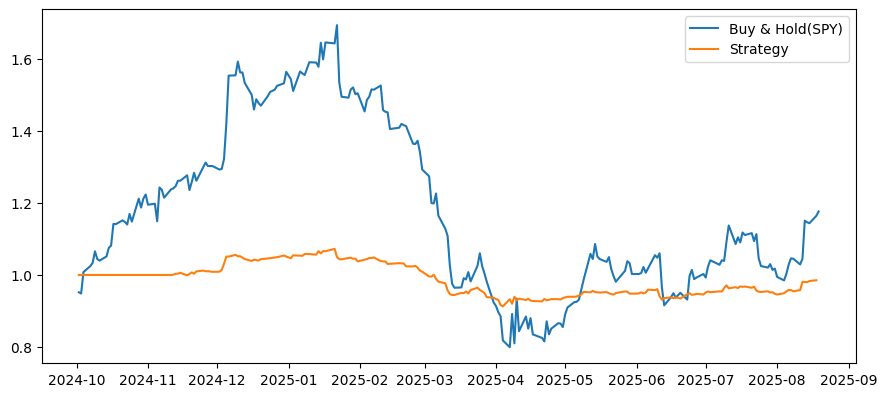

In [63]:
plt.figure(figsize=(10.5,4.6))
plt.plot(eq_bh.index,eq_bh.values,label='Buy & Hold(SPY)')
plt.plot(eq_strat.index,eq_strat.values,label='Strategy')
plt.legend()

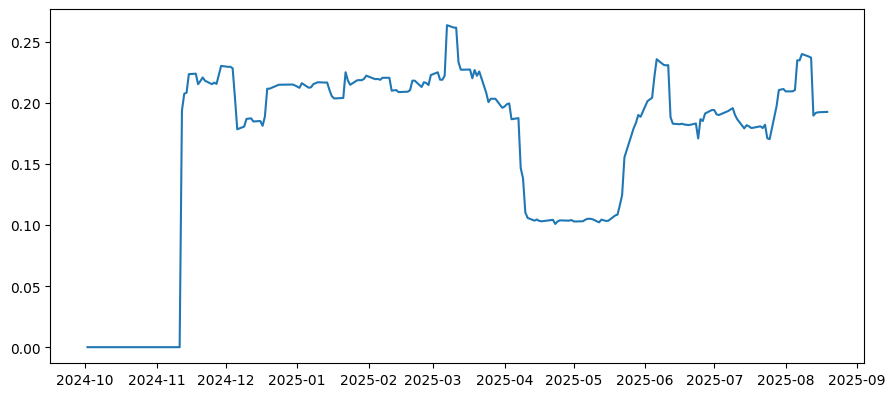

In [64]:
plt.figure(figsize=(10.5,4.6))
plt.plot(pos.index,pos.values,label='Position')
